# ***Deep Video Compression***

An emulation of traditional video codecs like `H.264` and `H.265` using a neural network in `PyTorch`. This begineer friendly notebook goes through building a neural codec for video compression with detailed explanations for each step.

The goal is to efficiently compress a video by predicting the next frame using the previous frame and transmitting only the motion and residuals between them. In a practical situation like video streaming, we can encode the motion and residual information of each frame, transmit these compressed bitstreams and decode it at the reciever's end to reconstruct the frames.

**Papers**:

[1] Lu, Guo, et al. "**DVC: An end-to-end deep video compression framework.**" CVPR (2019) (https://arxiv.org/abs/1812.00101).

[2] Yang, Ren et al.
"**OpenDVC: An Open Source Implementation of the DVC Video Compression Method**" (https://arxiv.org/abs/2006.15862)


**Dataset**: 
* [**Vimeo 90k** Septuplet Dataset](https://www.kaggle.com/datasets/wangsally/vimeo-90k-9)

**Other References**:
* **GitHub**: [facebookresearch/NeuralCompression](https://github.com/facebookresearch/NeuralCompression)

> "Learning based optical flow estimation is utilized to obtain the motion information and reconstruct the current frames.
> Then we employ two auto-encoder style neural networks to compress the corresponding motion and residual information.
> All the modules are jointly learned through a single loss function, in which they collaborate with each other by considering the trade-off between reducing the number of compression bits and improving quality of the decoded video."[1]

> "Experimental results show that the proposed approach can outperform the widely used video coding standard H.264 in terms of PSNR and be even on par with the latest standard H.265 in terms of MS-SSIM."[1]

#### Installing Prerequisites

- `CompressAI` is a PyTorch library focused on deep learning for data compression. It's specifically designed for developing end-to-end image and video compression models.
- `FVCore` or *Facebook Vision Core* provides common functionality for computer vision research.
- `LPIPS` or *Learned Perceptual Image Patch Similarity* is a metric for evaluating visual quality of images. Unlike `PSNR`(*Peak Signal-to-Noise Ratio*) or `SSIM`(*Structural Similarity*), `LPIPS` aligns better with human perception.

In [2]:
!pip install -q compressai
!pip install -q fvcore
!pip install -q lpips

#### Imports

- The `torch.nn.functional` module gives access to functional operations — activations (`F.relu`), losses (`F.cross_entropy`), convolutions (`F.conv2d`), etc., used directly without defining layers.
- The `torch.optim` module contains optimization algorithms like SGD, Adam etc. used for updating model weights during training.
- `nn` contains neural network layers like `nn.Conv2d`, `nn.Linear` etc.
- The `EntropyBottleneck` is a learnable module (just like a layer in a neural network) which learns to model the data's entropy by adjusting the shape and scale of its probability distribution. Further details below.

In [3]:
from typing import Any, List, NamedTuple, Optional, Sequence, Tuple, Callable, Union

In [4]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from compressai.entropy_models import EntropyBottleneck
from torch import Tensor, nn

/usr/local/lib/python3.11/dist-packages/compressai/models/video/google.py:353: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @amp.autocast(enabled=False)


## DVC


### *Components*

Previous frame — $x_{ref}$ (frame at time $t - 1$)

Target frame — $x_{target}$ (frame at time $t$)

#### 1. Motion Estimation

*Guessing how things moved in the next frame.* A convolutional motion estimation network predicts optical flow; a dense field indicating how each pixel moved from $x_{ref}$ to $x_{target}$. The output is the **Motion Latent**: $$y_{motion}$$

#### 2. Motion Compression

*Compressed representation of the motion estimation.* The motion latent is passed through an **Entropy Bottleneck** which does the following:
- Quantization of $y_{motion}$ into discrete values
- Estimate the probability distribution of those values
- *Rate Estimation* (how many bits needed) and *Entropy Coding* (compression)

After compression, the motion is decoded to construct the approximate **optical flow**: $$\hat{f}$$

#### 3. Motion Compensation (Warping)

*Constructing the new frame from the old one using the compressed motion.* The reference frame $x_{ref}$ is warped according to the optical flow $\hat{f}$, which produces a **motion compensated predicted frame**: $$\hat{x}_{pred}$$

#### 4. Residual Computation ($r$)

*Error / difference between the actual frame and the warped frame.*

$$r = x_{target} - \hat{x}_{pred}$$

This captures the details not explained in the optical flow, i.e. unforseen changes.

#### 5. Residual Compression

The residual $r$ is encoded by the **Residual Encoder** to obtain **Residual Latent**: $$y_{residual}$$
$y_{residual}$ is passed through another Entropy Bottleneck which does quantization, probability estimation, compression and rate control of the residual. Then the residual latent is decoded back to reconstruct the approximate residual $$\hat{r}$$

#### 6. Frame Reconstruction


The final reconstructed frame is obtained:
$$\hat{x} = \hat{x}_{pred} + \hat{r}$$

Thus the new frame is a combination of motion-compensated prediction and residual correction.

### Training Objective

The model is trained by minimizing **Rate-Distortion Loss**:

$$
L = R_{motion} + R_{residual} + \lambda \cdot D
$$

where:
- $R_{motion}$ - Estimated bits for motion latent $y_{motion}$
- $R_{residual}$ - Estimated bits for residual latent $y_{residual}$
- $\lambda$ - Trade-off parameter between rate/compression and distortion/quality.
- $D$ - Distortion between $x_{target}$ and $\hat{x}$ (`MSE` or `MS-SIM`)

### Flow

```mermaid
graph TD
    subgraph " " 
        A[Previous Frames x_ref, x_target]
    end
    A --> B(Motion Estimation Network)
    subgraph " "
        B --> C[EntropyBottleneck]
        C --> D1[Motion Decoder]
        C --> D2[Quantized Motion]
        D1 --> E[Motion Vectors]
        E --> F[Warping Operation]
    end
    subgraph " "
    F --> G[Predicted Frame x̂_pred]
    end
    subgraph " "
    D2 --> F
    G --> H(Residual Computation)
    H --> I[Residual Encoder + EntropyBottleneck → Residual ]
    I --> J[Residual Decoder]
    end
    subgraph " "
    J --> K[Final Reconstructed Frame → x̂]
    end
```

#### P-frame

A `P-frame` or **Predicted Frame** is a frame that stores only the changes relative to a previous frame instead of storing a full image.
It depends on a previously decoded frame — an `I-frame`(full image) or another P-frame through motion compensation.
P-frame stores the *motion vectors* and *residual data*.

In [5]:
# Compressed P-Frame Class
class CompressedPFrame(NamedTuple):
    """
    Output of DVC model compressing a single frame.
    Holds everything needed to decode one P-frame.

    Args:
        compressed_flow: Flow fields compressed to a string.
        flow_decomp_sizes: Metadata for the size of the flow representations at
            each compression level.
        compressed_residual: Residual compressed to a string.
        residual_decomp_sizes: Metadata for the size of the residual
            representations at each compression level.
    """

    compressed_flow: Any
    flow_decomp_sizes: List[torch.Size]
    compressed_residual: Any
    residual_decomp_sizes: List[torch.Size]

In [6]:
# DVC Training Output class
class DVCTrainOutput(NamedTuple):
    """
    Output of DVC forward function.
    Carries both quality and rate needed for rate-distortion loss calculation.

    Args:
        flow: The calculated optical flow field.
        image2_est: An estimate of image2 using the flow field and residual.
        residual: The residual between the flow-compensated ``image1`` and the
            true ``image2``.
        flow_probabilities: Estimates of probabilities of each compressed flow
            latent using entropy bottleneck.
        resid_probabilities: Estimates of probabilities of each compressed
            residual latent using entropy bottleneck.
    """

    flow: Tensor
    image2_est: Tensor
    residual: Tensor
    flow_probabilities: Tensor
    resid_probabilities: Tensor

In [7]:
# Dense Image Wrap functions: Wrap frame1 toward frame2 using Optical Flow
def _create_dense_warp_base_grid(
    dim1: int,
    dim2: int,
    dtype: Optional[torch.dtype] = None,
    device: Optional[torch.device] = None,
) -> Tensor:
    """Basic wrapper for meshgrid."""
    if dtype is None:
        dtype = torch.get_default_dtype()
    if device is None:
        device = torch.device("cpu")

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1, 1, dim1, dtype=dtype, device=device),
        torch.linspace(-1, 1, dim2, dtype=dtype, device=device),
        indexing="ij",
    )

    # for gridding we need to flip the order here
    base_grid = torch.stack((grid_x, grid_y), dim=-1)

    return base_grid.unsqueeze(0)


def dense_image_warp(
    image: Tensor,
    flow: Tensor,
    mode: str = "bilinear",
    padding_mode: str = "border",
    align_corners: bool = False,
) -> Tensor:
    r"""
    Warp image based on flow grid.

    Designed to mimic behavior of ``tf.contrib.image.dense_image_warp``. This
    function uses ``torch.nn.functional.grid_sample`` as its interpolation
    backend.

    * This function essentially applies inverse optical flow, i.e., for an
      image function :math:`f(x)`, we compute :math:`f(x+\delta)`, where
      :math:`\delta` is the flow. The flow uses the normalized grid in
      ``[-1, 1]`` as detailed in ``torch.nn.functional.grid_sample``. See
      ``torch.nn.functional.grid_sample`` for details.

    Args:
        image: Input image to be warped.
        flow: Optical flow field for applying warp. Can be different size than
            ``image``.
        mode: Interpolation mode to calculate output values ``'bilinear'`` |
            ``'nearest'`` | ``'bicubic'``. Default: ``'bilinear'``.
        padding_mode: Padding mode for outside grid values ``'zeros'`` |
            ``'border'`` | ``'reflection'``.
        align_corners: Whether to align corners. See
            ``torch.nn.functional.grid_sample``.

    Returns:
        The warped image.
    """
    if (not image.dtype == flow.dtype) or (not image.device == flow.device):
        raise ValueError("Either dtype or device not matched between inputs.")

    if not flow.shape[-1] == 2:
        raise ValueError("dense_image_warp only implemented for 2D images.")

    base_grid = _create_dense_warp_base_grid(
        flow.shape[1], flow.shape[2], dtype=image.dtype, device=image.device
    ).repeat(flow.shape[0], 1, 1, 1)

    return F.grid_sample(
        image,
        base_grid + flow,
        mode=mode,
        padding_mode=padding_mode,
        align_corners=align_corners,
    )

**DVC Class**

```mermaid
flowchart LR
    A[Motion Estimator \nDVCPyramidFlowEstimator] --> B[Motion Autoencoder]
    B --> C[Motion Compensation \nDVCMotionCompensationModel]
    C --> D[Residual Autoencoder]
```
```mermaid
graph TD
    subgraph "Autoencoder"
        A[DVCCompressionEncoder] --> B[EntropyBottleneck]
        B --> C[DVCCompressionDecoder]
    end
```

In [8]:
# DVC Class
class DVC(nn.Module):
    """
    Deep Video Compression composition class.

    This composes the Deep Video Compression Module of Lu (2019). It requires
    defining a motion estimator, a motion autoencoder, a motion compensator,
    and a residual autoencoder. The individual modules can be input by the
    user. If the user does not input a module, then this class will construct
    the module with default parameters from the paper.

    Lu, Guo, et al. "DVC: An end-to-end deep video compression framework."
    CVPR (2019).

    Args:
        coder_channels: Number of channels to use for autoencoders.
        motion_estimator: A module for estimating motion. See
            ``DVCPyramidFlowEstimator`` for an example.
        motion_encoder: A module for encoding motion fields. See
            ``DVCCompressionEncoder`` for an example.
        motion_entropy_bottleneck: A module for quantization and latent
            probability estimation for the compressed motion fields. See
            ``EntropyBottleneck`` for an example.
        motion_decoder: A module for decoding motion fields. See
            ``DVCCompressionDecoder`` for an example.
        motion_compensation: A module for compensating for motion errors. See
            ``DVCMotionCompensationModel`` for an example.
        residual_encoder: A module for encoding residuals after motion
            compensation. See ``DVCCompressionEncoder`` with 3 input channels
            for an example.
        residual_entropy_bottleneck: A module for quantization and latent
            probability estimation for the compressed residuals. See
            ``EntropyBottleneck`` for an example.
        residual_decoder: A module for decoding residuals. See
            ``DVCCompressionEncoder`` with 3 output channels for an example.
    """

    def __init__(
        self,
        coder_channels: int = 128,
        motion_estimator: Optional[nn.Module] = None,
        motion_encoder: Optional[nn.Module] = None,
        motion_entropy_bottleneck: Optional[nn.Module] = None,
        motion_decoder: Optional[nn.Module] = None,
        motion_compensation: Optional[nn.Module] = None,
        residual_encoder: Optional[nn.Module] = None,
        residual_entropy_bottleneck: Optional[nn.Module] = None,
        residual_decoder: Optional[nn.Module] = None,
    ):
        super().__init__()

        self.motion_estimator = (
            DVCPyramidFlowEstimator() if motion_estimator is None else motion_estimator
        )
        self.motion_encoder = (
            DVCCompressionEncoder(
                filter_channels=coder_channels, out_channels=coder_channels
            )
            if motion_encoder is None
            else motion_encoder
        )
        self.motion_entropy_bottleneck = (
            EntropyBottleneck(coder_channels)
            if motion_entropy_bottleneck is None
            else motion_entropy_bottleneck
        )
        self.motion_decoder = (
            DVCCompressionDecoder(
                in_channels=coder_channels, filter_channels=coder_channels
            )
            if motion_decoder is None
            else motion_decoder
        )
        self.motion_compensation = (
            DVCMotionCompensationModel()
            if motion_compensation is None
            else motion_compensation
        )
        self.residual_encoder = (
            DVCCompressionEncoder(
                in_channels=3,
                filter_channels=coder_channels,
                out_channels=coder_channels,
                kernel_size=5,
            )
            if residual_encoder is None
            else residual_encoder
        )
        self.residual_entropy_bottleneck = (
            EntropyBottleneck(coder_channels)
            if residual_entropy_bottleneck is None
            else residual_entropy_bottleneck
        )
        self.residual_decoder = (
            DVCCompressionDecoder(
                in_channels=coder_channels,
                filter_channels=coder_channels,
                out_channels=3,
                kernel_size=5,
            )
            if residual_decoder is None
            else residual_decoder
        )

    def compress(self, image1: Tensor, image2: Tensor) -> CompressedPFrame:
        """
        Compute compressed motion and residual between two images.

        Note:
            You must call ``update`` prior to calling ``compress``.

        Args:
            image1: The first image.
            image2: The second image.

        Returns:
            CompressedPFrame tuple with 1) the compressed flow field, 2) the
            flow decomposition sizes, 3) the compressed residual, and 4) the
            residual decomposition sizes.
        """
        flow = self.motion_estimator(image1, image2)

        # compress optical flow fields
        flow_latent, flow_decomp_sizes = self.motion_encoder(flow)
        compressed_flow = self.motion_entropy_bottleneck.compress(flow_latent)
        flow_latent = self.motion_entropy_bottleneck.decompress(
            compressed_flow, flow_latent.shape[-2:]
        )
        flow = self.motion_decoder(flow_latent, flow_decomp_sizes)

        # apply optical flow fields
        image2_est = dense_image_warp(image1, flow.permute(0, 2, 3, 1))

        # compensate for optical flow errors
        image2_est = self.motion_compensation(image1, image2_est, flow)

        # encode final residual
        residual = image2 - image2_est
        residual_latent, resid_decomp_sizes = self.residual_encoder(residual)
        compressed_residual = self.residual_entropy_bottleneck.compress(residual_latent)

        return CompressedPFrame(
            compressed_flow,
            flow_decomp_sizes,
            compressed_residual,
            resid_decomp_sizes,
        )

    def decompress(self, image1: Tensor, compressed_pframe: CompressedPFrame) -> Tensor:
        """
        Decompress motion fields and residual and compute next frame estimate.

        Args:
            image1: The base image for computing the next frame estimate.
            compressed_pframe: A compressed P-frame and metadata.

        Returns:
            An estimate of ``image2`` using ``image1`` and the compressed
                transition information.
        """
        flow_latent_size = (
            compressed_pframe.flow_decomp_sizes[-1][-2] // 2,
            compressed_pframe.flow_decomp_sizes[-1][-1] // 2,
        )
        flow_latent = self.motion_entropy_bottleneck.decompress(
            compressed_pframe.compressed_flow, flow_latent_size
        )
        flow = self.motion_decoder(flow_latent, compressed_pframe.flow_decomp_sizes)

        # apply optical flow fields
        image2_est = dense_image_warp(image1, flow.permute(0, 2, 3, 1))

        # compensate for optical flow errors
        image2_est = self.motion_compensation(image1, image2_est, flow)

        # decode residual
        residual_latent_size = (
            compressed_pframe.residual_decomp_sizes[-1][-2] // 2,
            compressed_pframe.residual_decomp_sizes[-1][-1] // 2,
        )
        residual_latent = self.residual_entropy_bottleneck.decompress(
            compressed_pframe.compressed_residual, residual_latent_size
        )
        residual = self.residual_decoder(
            residual_latent, compressed_pframe.residual_decomp_sizes
        )

        return (image2_est + residual).clamp_(0, 1)

    def update(self, force: bool = True) -> bool:
        """
        Updates the entropy bottleneck(s) CDF values.

        Needs to be called once after training to be able to later perform the
        evaluation with an actual entropy coder.

        Args:
            force: Overwrite previous values.
        """
        update1 = self.motion_entropy_bottleneck.update(force=force)
        update2 = self.residual_entropy_bottleneck.update(force=force)

        return update1 or update2

    def forward(self, image1: Tensor, image2: Tensor) -> DVCTrainOutput:
        """
        Apply DVC coding to a pair of images.

        The ``forward`` function is expected to be used for training. For
        inference, see the ``compress`` and ``decompress``.

        Args:
            image1: The base image.
            image2: The second image. Optical flow will be applied to
                ``image1`` to predict ``image2``.

        Returns:
            A 5-tuple training output containing 1) the calculated optical
            flow, 2) an estimate of ``image2`` including motion compensation,
            3) the residual between ``image2`` and its estimate, 4) the
            probabilities output by the flow quantizer, and 5) the
            probabilities output by the residual quantizer.
        """
        # estimate optical flow fields
        flow = self.motion_estimator(image1, image2)

        # compress optical flow fields
        flow, sizes = self.motion_encoder(flow)
        flow, flow_probabilities = self.motion_entropy_bottleneck(flow)
        flow = self.motion_decoder(flow, sizes)

        # apply optical flow fields
        image2_est = dense_image_warp(image1, flow.permute(0, 2, 3, 1))

        # compensate for optical flow errors
        image2_est = self.motion_compensation(image1, image2_est, flow)

        # encode final residual
        residual = image2 - image2_est
        residual, sizes = self.residual_encoder(residual)
        residual, resid_probabilities = self.residual_entropy_bottleneck(residual)
        residual = self.residual_decoder(residual, sizes)

        image2_est = image2_est + residual

        return DVCTrainOutput(
            flow, image2_est, residual, flow_probabilities, resid_probabilities
        )

#### Autoencoders

1. `DVCCompressionEncoder`: Repeated `Conv`→`GDN`/`BatchNorm`→`ReLU` followed by a final `Conv`.
    

2. `DVCCompressionDecoder`: Mirrors the encoder (`ConvTranspose2D`→`InverseGDN`/`BatchNorm`→`ReLU`).

In [9]:
class DVCCompressionDecoder(nn.Module):
    """
    Deep Video Compression decoder module.

    Args:
        in_channels: Number of channels in latent space.
        out_channels: Number of channels to output from decoder.
        filter_channels: Number of channels for intermediate layers.
        kernel_size: Size of convolution kernels.
        stride: Stride of convolutions.
        num_conv_layers: Number of convolution layers.
        use_gdn: Whether to use Generalized Divisive Normalization or
            BatchNorm.
    """

    def __init__(
        self,
        in_channels: int = 128,
        out_channels: int = 2,
        filter_channels: int = 128,
        kernel_size: int = 3,
        stride: int = 2,
        num_conv_layers: int = 4,
        use_gdn: bool = True,
    ):
        super().__init__()
        padding = kernel_size // 2
        bias = True if use_gdn else False

        self.layers = nn.ModuleList()
        for _ in range(num_conv_layers - 1):
            self.layers.append(
                nn.ConvTranspose2d(
                    in_channels=in_channels,
                    out_channels=filter_channels,
                    kernel_size=kernel_size,
                    padding=padding,
                    stride=stride,
                    bias=bias,
                )
            )
            if use_gdn:
                self.layers.append(SimplifiedInverseGDN(filter_channels))
            else:
                self.layers.append(nn.BatchNorm2d(filter_channels))
                self.layers.append(nn.ReLU())

            in_channels = filter_channels

        self.layers.append(
            nn.ConvTranspose2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                padding=padding,
                stride=stride,
                bias=True,
            )
        )

    def forward(
        self, image: Tensor, output_sizes: Optional[Sequence[torch.Size]] = None
    ) -> Tensor:
        # validate output_sizes
        if output_sizes is not None:
            output_sizes = [os for os in output_sizes]  # shallow copy
            transpose_conv_count = 0
            for layer in self.layers:
                if isinstance(layer, nn.ConvTranspose2d):
                    transpose_conv_count += 1
            if not transpose_conv_count == len(output_sizes):
                raise ValueError(
                    "len(output_sizes) must match number of transpose convolutions."
                )

        # run the deconvolutions
        for layer in self.layers:
            # use sizes from encoder if we have them for decoding
            if isinstance(layer, nn.ConvTranspose2d) and output_sizes is not None:
                image = layer(image, output_sizes.pop())
            else:
                image = layer(image)

        return image

In [10]:
class DVCCompressionEncoder(nn.Module):
    """
    Deep Video Compression encoder module.

    Args:
        in_channels: Number of channels in image space.
        out_channels: Number of channels to output from encoder.
        filter_channels: Number of channels for intermediate layers.
        kernel_size: Size of convolution kernels.
        stride: Stride of convolutions.
        num_conv_layers: Number of convolution layers.
        use_gdn: Whether to use Generalized Divisive Normalization or
            BatchNorm.
    """

    def __init__(
        self,
        in_channels: int = 2,
        out_channels: int = 128,
        filter_channels: int = 128,
        kernel_size: int = 3,
        stride: int = 2,
        num_conv_layers: int = 4,
        use_gdn: bool = True,
    ):
        super().__init__()
        padding = kernel_size // 2
        bias = True if use_gdn else False

        self.layers = nn.ModuleList()
        for _ in range(num_conv_layers - 1):
            self.layers.append(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=filter_channels,
                    kernel_size=kernel_size,
                    padding=padding,
                    stride=stride,
                    bias=bias,
                )
            )
            if use_gdn:
                self.layers.append(SimplifiedGDN(filter_channels))
            else:
                self.layers.append(nn.BatchNorm2d(filter_channels))
                self.layers.append(nn.ReLU())

            in_channels = filter_channels

        self.layers.append(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                padding=padding,
                stride=stride,
                bias=True,
            )
        )

    def forward(self, image: Tensor) -> Tuple[Tensor, List[torch.Size]]:
        sizes = []
        for layer in self.layers:
            # log the sizes so that we can recover them with strides != 1
            if isinstance(layer, nn.Conv2d):
                sizes.append(image.shape)

            image = layer(image)

        return image, sizes

#### GDN

**Generalized Divisive Normalization** is a non-linear activation function used in the field of image compression. The fundamental concept behind GDN is to normalize the activity of a neuron by dividing its response by a weighted pool of activities of other nearby neurons. This is proven to decorrelate features better than ReLU for compression.

In [11]:
# Simplified GDN and Inverse GDN
class _ClampMin(torch.autograd.Function):
    """Based on https://github.com/jorge-pessoa/pytorch-gdn (MIT License)."""

    @staticmethod
    def forward(ctx, data, min):
        ctx.save_for_backward(data, torch.tensor(min))

        return data.clamp(min=min)

    @staticmethod
    def backward(ctx, grad):
        data, min = ctx.saved_tensors

        return grad * ((data >= min) | (grad < 0.0))


def _clamp_min(image: Tensor, min: float) -> Tensor:
    """Min clamping but preserving gradients."""
    return _ClampMin.apply(image, min)


class SimplifiedGDN(nn.Module):
    r"""
    Simplified Generalized Divisive Normalization (GDN).

    This applies the GDN layer, has been shown to be more useful for
    compression than other activation layers such as relu or tanh.
    Mathematically, it applies:

    .. math::
        z_i = \frac{x_i}{\beta_i + \sum_j \gamma_{ij}|x_j|}

    where :math:`\beta_i` and :math:`\gamma_{ij}` are trainable parameters.

    Johnston N, Eban E, Gordon A, Ballé J. Computationally efficient neural
    image compression. arXiv preprint arXiv:1912.08771. 2019 Dec 18.

    Args:
        channels: Number of channels in input.
        gamma_init: Initial value for ``gamma``.
        beta_min: Threshold for ``beta`` for numerical stability.
    """

    def __init__(self, channels: int, gamma_init: float = 0.1, beta_min: float = 1e-6):
        super().__init__()
        self.gamma = nn.Parameter(
            torch.eye(channels).view(channels, channels, 1, 1) * gamma_init
        )
        self.beta = nn.Parameter(torch.ones(channels))
        self.beta_min = beta_min

    def forward(self, image: Tensor) -> Tensor:
        r"""
        Apply forward GDN layer.

        Args:
            image: Input image of shape :math:`(N, C_{in}, H_{in}, W_{in})`.

        Returns:
            ``image`` after normalization.
        """
        # threshold for numerical stability while keeping backprop
        self.gamma.data = _clamp_min(self.gamma.data, 0)
        self.beta.data = _clamp_min(self.beta.data, self.beta_min)

        return image / F.conv2d(torch.abs(image), self.gamma, self.beta)


class SimplifiedInverseGDN(nn.Module):
    r"""
    Simplified Inverse Generalized Divisive Normalization (GDN).

    This applies the inverse GDN layer, has been shown to be more useful for
    compression than other activation layers such as relu or tanh.
    Mathematically, it applies:

    .. math::
        z_i = x_i * {\beta_i + \sum_j \gamma_{ij}|x_j|}

    where :math:`\beta_i` and :math:`\gamma_{ij}` are trainable parameters.

    Johnston N, Eban E, Gordon A, Ballé J. Computationally efficient neural
    image compression. arXiv preprint arXiv:1912.08771. 2019 Dec 18.

    Args:
        channels: Number of channels in input.
        gamma_init: Initial value for ``gamma``.
        beta_min: Threshold for ``beta`` for numerical stability.
    """

    def __init__(self, channels: int, gamma_init: float = 0.1, beta_min: float = 1e-6):
        super().__init__()
        self.gamma = nn.Parameter(
            torch.eye(channels).view(channels, channels, 1, 1) * gamma_init
        )
        self.beta = nn.Parameter(torch.ones(channels))
        self.beta_min = beta_min

    def forward(self, image: Tensor) -> Tensor:
        r"""
        Apply inverse GDN layer.

        Args:
            image: Input image of shape :math:`(N, C_{in}, H_{in}, W_{in})`.

        Returns:
            ``image`` after inverse normalization.
        """
        # threshold for numerical stability while keeping backprop
        self.gamma.data = _clamp_min(self.gamma.data, 0)
        self.beta.data = _clamp_min(self.beta.data, self.beta_min)

        return image * F.conv2d(torch.abs(image), self.gamma, self.beta)

#### Optical Flow Estimation 

`DVCPyramidFlowEstimator` builds a pyramid of images via average pooling. It performs a Top-Down Estimation, starting from the lowest resolution and predicting the flow. It upsamples and refines data at each finer level, and at the end returing the final flow along with each warped pair of frames.

In [12]:
class DVCPyramidFlowEstimator(nn.Module):
    """
    Pyramidal optical flow estimation.

    This estimates the optical flow at `levels` different pyramidal scales. It
    should be trained in conjunction with a pyramidal optical flow supervision
    signal.

    Args:
        in_channels: Number of input channels. Typically uses two 3-channel
            images, plus an initial flow with 2 more channels.
        filter_counts: Number of filters for each stage of pyramid. Defaults
            to ``[32, 64, 32, 16, 2]``.
        kernel_size: Kernel size of filters.
        levels: Number of pyramid levels.
    """

    def __init__(
        self,
        in_channels: int = 8,
        filter_counts: Optional[Sequence[int]] = None,
        kernel_size: int = 7,
        levels: int = 5,
    ):
        super().__init__()
        if filter_counts is None:
            filter_counts = [32, 64, 32, 16, 2]
        padding = kernel_size // 2
        self.model_levels = nn.ModuleList()

        for _ in range(levels):
            current_in_channels = in_channels
            layers: List[nn.Module] = []
            for i, filter_count in enumerate(filter_counts):
                layers.append(
                    nn.Conv2d(
                        in_channels=current_in_channels,
                        out_channels=filter_count,
                        kernel_size=kernel_size,
                        padding=padding,
                    )
                )
                if i < len(filter_counts) - 1:
                    layers.append(nn.ReLU())

                current_in_channels = filter_count

            self.model_levels.append(nn.Sequential(*layers))

    def _decompose_images_to_pyramids(
        self, image1: Tensor, image2: Tensor
    ) -> Tuple[List[Tensor], List[Tensor]]:
        """Pyramid flow structure, average down for each pyramid level."""
        images_1 = [image1]
        images_2 = [image2]
        for _ in range(1, len(self.model_levels)):
            images_1.append(F.avg_pool2d(images_1[-1], 2))
            images_2.append(F.avg_pool2d(images_2[-1], 2))

        return images_1, images_2

    def calculate_flow_with_image_pairs(
        self, image1: Tensor, image2: Tensor
    ) -> Tuple[Tensor, List[Tuple[Tensor, Tensor]]]:
        """
        Calculate optical flow and return image pairs for each pyramid level.

        During training, we optimize the optical flow by trying to match the
        flow at each pyramid scale to its target. This function computes the
        images output by the flow at each level of the pyramid and returns them
        all in addition to the final flow.

        Args:
            image1: The based image - a flow map will be computed to transform
                ``image1`` into ``image2``.
            image2: The target image.

        Returns:
            A 2-tuple containing:
                The pyramidal flow estimate.
                Base/target image pairs from each level of the pyramid that can
                    be input into a distortion function.
        """
        if not image1.shape == image2.shape:
            raise ValueError("Image shapes must match.")

        images_1, images_2 = self._decompose_images_to_pyramids(image1, image2)
        flow = torch.zeros_like(images_1[-1])[:, :2]  # just the first two channels

        # estimate flows at all levels and return warped images
        optical_flow_pairs = []
        for model_level in self.model_levels:
            image1 = images_1.pop()
            image2 = images_2.pop()
            flow = F.interpolate(flow, image1.shape[2:], mode="bilinear")
            flow = flow + model_level(
                torch.cat(
                    (
                        dense_image_warp(image1, flow.permute(0, 2, 3, 1)),
                        image2,
                        flow,
                    ),
                    dim=1,
                )
            )
            optical_flow_pairs.append(
                (dense_image_warp(image1, flow.permute(0, 2, 3, 1)), image2)
            )

        # we have to return all of the warped images at different levels for
        # training
        return flow, optical_flow_pairs

    def forward(self, image1: Tensor, image2: Tensor) -> Tensor:
        """
        Calculate optical flow using pyramidal structure and a learned model.

        Args:
            image1: The based image - a flow map will be computed to transform
                ``image1`` into ``image2``.
            image2: The target image.

        Returns:
            Pyramidal optical flow estimate.
        """
        return self.calculate_flow_with_image_pairs(image1, image2)[0]

#### Motion Compensation

`DVCMotionCompensationModel` is a U-Net-style Conv stack (U-Net is a popular CNN architecture) that takes 
$$
frame_1, warped\ frame_2, flow
$$
as input, and learns to correct any artifacts left by warping.

In [13]:
class DVCMotionCompensationModel(nn.Module):
    """
    Motion compensation model.

    After applying optical flow, there remain residual errors. This model
    corrects for the errors based on the input image, the transformed image,
    and the optical flow field.

    Args:
        in_channels: Number of input channels. The ``forward`` function takes
            as input two 3-channel images, plus an optical flow field, so by
            default this is 8 channels.
        model_channels: Number of channels for convolution kernels.
        out_channels: Number of channels for output motion-compensated image.
        kernel_size: Size of convolution kernels.
        num_levels: Number of convolution levels.
    """

    def __init__(
        self,
        in_channels: int = 8,
        model_channels: int = 64,
        out_channels: int = 3,
        kernel_size: int = 3,
        num_levels: int = 3,
    ):
        super().__init__()
        padding = kernel_size // 2

        # simple input layer
        input_layer = nn.Conv2d(
            in_channels=in_channels,
            out_channels=model_channels,
            kernel_size=kernel_size,
            padding=padding,
            bias=True,
        )

        # build the autoencoder portion from the ground up
        child = None
        for _ in range(num_levels):
            child = _MotionCompensationLayer(
                child, in_channels=model_channels, out_channels=model_channels
            )
        unet = child

        # make sure we turn on bias for the output
        output_layer = nn.Sequential(
            nn.Conv2d(
                in_channels=model_channels,
                out_channels=model_channels,
                kernel_size=kernel_size,
                padding=padding,
                bias=True,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=model_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                padding=padding,
                bias=True,
            ),
        )

        assert unet is not None
        self.model = nn.Sequential(input_layer, unet, output_layer)

    def forward(self, image1: Tensor, image2: Tensor, flow: Tensor) -> Tensor:
        return self.model(torch.cat((image1, image2, flow), dim=1))

# One layer of DVCMotionCompensationModel
class _MotionCompensationLayer(nn.Module):
    """
    Intermediate U-Net style layer for motion compensation.

    Args:
        child: The motion compensation module executes a U-Net style
            convolution structure with an input convolution followed by a child
            ``_MotionCompensationLayer`` followed by an output convolution. If
            the layer is at the bottom of the 'U', then a ``None`` is input for
            ``child``.
        in_channels: Number of input channels for convolutions.
        out_channels: Number of outpout channels for convolutions.
    """

    def __init__(
        self,
        child: Optional[nn.Module] = None,
        in_channels: int = 64,
        out_channels: int = 64,
    ):
        super().__init__()
        self.child = child
        self.input_block = _ResidualBlock(
            in_channels=in_channels, out_channels=out_channels
        )
        self.output_block = _ResidualBlock(
            in_channels=in_channels, out_channels=out_channels
        )

    def forward(self, image: Tensor) -> Tensor:
        upsample_size = tuple(image.shape[2:])

        # residual block includes skipped connection
        image = self.input_block(image)

        # if we have a child, downsample, run it, and then upsample back
        if self.child is not None:
            image = image + F.interpolate(
                self.child(F.avg_pool2d(image, kernel_size=2)),
                size=upsample_size,
                mode="nearest",
            )

        # residual block includes skipped connection
        return self.output_block(image)

# Pre-activated ResNet block
class _ResidualBlock(nn.Module):
    """
    Simple pre-activated ResNet-style block.

    Structure: input -> ReLU -> Conv2d -> ReLU -> Conv2d + input

    Args:
        in_channels: Number of input channels.
        out_channels: Number of output channels.
        stride: Stride of convolutions.
    """

    def __init__(
        self,
        kernel_size: int = 3,
        in_channels: int = 64,
        out_channels: int = 64,
        stride: int = 1,
    ):
        super().__init__()
        padding = kernel_size // 2

        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=in_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=True,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=True,
            ),
        )

    def forward(self, image: Tensor) -> Tensor:
        return image + self.block(image)

# Datasets

In [14]:
import os
from pathlib import Path

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets.folder import default_loader
from torchvision.transforms import ToTensor

> `Dataset` is to create custom datasets.
> `DataLoader` is to load data in batches. 
> `default_loader` loads the images as PIL (Python Image Library) images.
> `ToTensor` converts PIL or NumPy arrays to PyTorch tensors.

### Vimeo 90k

The dataset consists of a set of septuplet (groups of 7) directories, where each directory contains seven consecutive frames of a video from *vimeo.com*.
Each frame is stored as a PNG file. 
This class can be configured to return videos (consecutive frames in a septuplet) or individual images every time an item is accessed.

The `Vimeo90kSeptuplet` class loads sequences of frames from the dataset. We use 

In [15]:
class Vimeo90kSeptuplet(Dataset):
    """
    Loads images or videos from the Vimeo-90k septuplet dataset. 

    Note:
        Following the conventions of ``torchvision``, in video mode this
        dataset will have a default transform of
        ``torchvision.transforms.ToTensor``, while in image mode no default
        transform is provided.

    Args:
        root: Path to the Vimeo-90k root directory (i.e. the
            directory containing the dataset's README).
        as_video: Determines whether the dataset should return
            individual images (``as_video=False``) or
            multiple consecutive frames  (``as_video=True``)
            at a time.
        frames_per_group: The number of frames to include from
            each septuplet. Specifically, the first ``frames_per_group``
            frames from each septuplet are included in
            the dataset. Must be between 1 and 7.
        split: Specifies which dataset parition should be used. Valid values
            are ``"train"`` or ``"test"``. Exactly one of ``split`` or
            'folder_list' must be specified.
        folder_list: A list of paths to septuplets to include in the dataset
            split. Each septuplet path must be a directory containing the files
            ``im1.png``, ..., ``im7.png``. Exactly one of ``split`` or
            ``folder_list`` must be specified.
        pil_transform: Callable object for applying transforms to
            the PIL images prior to image concatenation. If using, be sure to
            have the final operation convert the PIL image to a tensor.
            Following ``torchvision``'s dataset conventions, the default
            transform is ``torchvision.transforms.ToTensor`` when
            in video mode (i.e. when ``as_video=True``), while no
            default transform is applied in image mode.
        tensor_transform: Callable object for applying PyTorch
            transforms after data conversion and septuplet concatenation.
    """

    def __init__(
        self,
        root: Union[str, os.PathLike],
        as_video: bool = False,
        frames_per_group: int = 7,
        split: Optional[str] = None,
        folder_list: Optional[Sequence[str]] = None,
        pil_transform: Optional[Callable[[Any], Tensor]] = None,
        tensor_transform: Optional[Callable[[Tensor], Tensor]] = None,
    ):
        self.root = Path(root)
        self.as_video = as_video

        if frames_per_group not in list(range(1, 8)):
            raise ValueError(
                "frames_per_group must be an integer between 1 and 7 (inclusive), "
                f"not '{frames_per_group}'"
            )

        self.frames_per_group = frames_per_group
        self.pil_transform = (
            ToTensor() if pil_transform is None and as_video else pil_transform
        )
        self.tensor_transform = tensor_transform

        if (split is None) == (folder_list is None):
            raise ValueError("Exactly one of 'split', 'folder_list' must be specified.")

        if folder_list is not None:
            self.folder_list = folder_list
        else:
            if split not in ["train", "test"]:
                raise ValueError(
                    "split must take on values of either 'train' or 'test', "
                    f"not {split}"
                )

            with open(self.root / f"sep_{split}list.txt", "r") as file:
                self.folder_list = [
                    "sequence/" + fname.strip() for fname in file.readlines()
                ]

    def __len__(self) -> int:
        if self.as_video:
            return len(self.folder_list)
        else:
            return len(self.folder_list) * self.frames_per_group

    def load_image(self, septuplet: Path, frame_number: int) -> Tensor:
        img_path = default_loader(str(septuplet / f"im{frame_number}.png"))
        img = self.pil_transform(img_path)
        if not isinstance(img, Tensor):
            raise RuntimeError(
                "Tensor not returned from pil_transform. "
                "Did you forget to add ToTensor() to your transform?"
            )
        return img

    def __getitem__(self, idx: int) -> Tensor:
        if self.as_video:
            folder = self.root / self.folder_list[idx]
            images = []
            for im_num in range(1, self.frames_per_group + 1):
                images.append(self.load_image(folder, im_num))

            item: Tensor = torch.stack(images)

        else:
            folder_idx = idx // self.frames_per_group
            frame_idx = idx % self.frames_per_group + 1

            folder = self.root / self.folder_list[folder_idx]
            item = self.load_image(folder, frame_idx)

        if self.tensor_transform is not None:
            item = self.tensor_transform(item)

        return item

In [16]:
dataset_root = "/kaggle/input/vimeo-90k-9"

In [17]:
# Create Train and Test Datasets

# Create the training dataset
train_dataset = Vimeo90kSeptuplet(
    root=dataset_root,
    as_video=True,  # Load sequences of frames
    frames_per_group=7,  # Use all 7 frames in each sequence
    split="train",  # Use the training split
)

# Create the test dataset
test_dataset = Vimeo90kSeptuplet(
    root=dataset_root,
    as_video=True,
    frames_per_group=7,
    split="test",
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=4)

In [22]:
# Initialize the model
model = DVC(coder_channels=128)

# Move the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# If using Settings→Accelerator→GPU T4 x2 in Kaggle
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    # Use both GPUs
    model = nn.DataParallel(model)
    
model = model.to(device)

Using 2 GPUs


# Training

- Optimizer updates the model's weights to minimize the loss function during training.
`Adam`(**Adaptive Moment Estimation**) is the type of optimizer used here with learning rate $0.0001$.
- Criterion is the loss function used — Mean Squared Error Loss.

In [23]:
# Define the optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()  # Example: Mean Squared Error for reconstruction

In [24]:
# Training loop
num_epochs = 100

In [25]:
# # Temporary -- for continuing training from a saved model
# model = DVC()
# model.load_state_dict(torch.load("/kaggle/working/dvc_model_epoch_7.pth"))
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# if torch.cuda.device_count() > 1:
#     print(f"Using {torch.cuda.device_count()} GPUs")
#     model = nn.DataParallel(model)
    
# model = model.to(device)

In [ ]:
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    batch_num = 0

    for batch in train_loader:
        batch_num += 1
        # Load a batch of video sequences
        batch = batch.to(device)  # Move to GPU if available

        # Use the first frame as the reference and the second frame as the target
        image1 = batch[:, 0]  # First frame
        image2 = batch[:, 1]  # Second frame

        # Forward pass
        output = model(image1, image2)

        # Compute the loss
        loss = criterion(output.image2_est, image2)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) > 10 and (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"dvc_model_epoch_{epoch + 1}.pth")
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

Epoch 1/100, Loss: 0.003008871599049928
Epoch 2/100, Loss: 0.0011101470515689177
Epoch 3/100, Loss: 0.0008255049750376926
Epoch 4/100, Loss: 0.0006243907874183523
Epoch 5/100, Loss: 0.0005228277017214223
Epoch 6/100, Loss: 0.00043776868073342617
Epoch 7/100, Loss: 148.817301464358
Epoch 8/100, Loss: 0.11151540098184139
Epoch 9/100, Loss: 0.07956742357467464
Epoch 10/100, Loss: 0.058181673587139646
Epoch 11/100, Loss: 0.04223779462914032
Epoch 12/100, Loss: 0.031311246536354045
Epoch 13/100, Loss: 0.023785594525478328
Epoch 14/100, Loss: 0.018874129473218478
Epoch 15/100, Loss: 0.015617384995788066
Epoch 16/100, Loss: 0.01299318975502719
Epoch 17/100, Loss: 0.01076954078859376
Epoch 18/100, Loss: 0.008944849787282372
Epoch 19/100, Loss: 0.007315068878293673
Epoch 20/100, Loss: 0.0060133035803746245


In [ ]:
torch.save(model.state_dict(), f"dvc_model.pth")

# Evaluation: ToDo

In [ ]:
# Evaluate the model on the Test Dataset
# model.eval()
# with torch.no_grad():
#     total_loss = 0

#     for batch in test_loader:
#         batch = batch.to(device)

#         image1 = batch[:, 0]
#         image2 = batch[:, 1]

#         output = model(image1, image2)
#         loss = criterion(output, image2)

#         total_loss += loss.item()

#     print(f"Test Loss: {total_loss / len(test_loader)}")

# Usage

In [26]:
# Load the model for use
saved_model = DVC()

# Load saved model
state_dict = torch.load('/kaggle/input/dvc/pytorch/default/1/dvc_model_epoch_10.pth', map_location='cpu')

/tmp/ipykernel_31/3344151941.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('/kaggle/input/dvc/pytorch/default/1/dvc_model_epoch_10.pth', map_lo

In [1]:
# Since 2 GPUs are used for training in Kaggle via nn.DataParallel(), we need to
# remove 'module.' from all keys if present 
from collections import OrderedDict

new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k.replace('module.', '')  # Remove 'module.' prefix
    new_state_dict[name] = v

# Load into the model
saved_model.load_state_dict(new_state_dict)
saved_model.eval()

NameError: name 'state_dict' is not defined

In [28]:
import cv2

# Function to load and preprocess a frame
def load_frame(file_path):
    # Load image using OpenCV; note cv2 loads images as BGR.
    frame = cv2.imread(file_path)
    if frame is None:
        raise ValueError(f"Could not read image: {file_path}")
    # Convert to RGB
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # Normalize to [0, 1] and convert to float32
    frame = frame.astype(np.float32) / 255.0
    # Convert to torch tensor and move to shape [1, 3, H, W]
    frame_tensor = torch.from_numpy(frame).permute(2, 0, 1).unsqueeze(0)
    return frame_tensor

Frame 0 and 1...


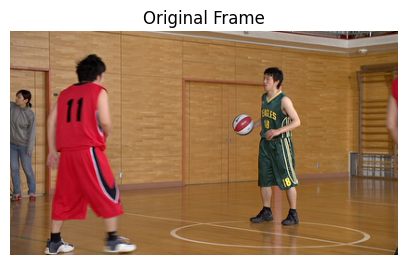

In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as plt

frames_folder = '/kaggle/input/basketballpass/BasketballPass'
image_files = sorted(glob.glob(os.path.join(frames_folder, '*.png')))

# Update the entropy models (required before using compression functions)
saved_model.update(force=True)

# Process consecutive frame pairs
reconstructed_frames = []
for i in range(10):
    print(f"Frame {i} and {i + 1}...")

    image1 = load_frame(image_files[i])
    image2 = load_frame(image_files[i + 1])


    # If we have a GPU, move to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    image1, image2 = image1.to(device), image2.to(device)
    saved_model.to(device)

    orig_frame = load_frame(image_files[i + 1]).squeeze(0).permute(1,2,0).numpy()

    # Display original frame
    plt.figure(figsize=(5, 5))
    plt.imshow(orig_frame)
    plt.title("Original Frame")
    plt.axis("off")
    plt.show()

    # Compress image pair
    compressed_pframe = saved_model.compress(image1, image2)

    # Decompress to reconstruct image2
    image2_reconstructed = saved_model.decompress(image1, compressed_pframe)
    reconstructed_frames.append(image2_reconstructed.cpu().detach())

    recon_frame = reconstructed_frames[i].squeeze(0).permute(1,2,0).numpy()

    # Display reconstructed frame
    plt.figure(figsize=(5, 5))
    plt.imshow(recon_frame)
    plt.title("Reconstructed Frame")
    plt.axis("off")
    plt.show()

In a **practical situation** where traditional codecs like **H.264** are used (e.g., video streaming, storage, conferencing), if you have a **trained DVC model**, you would replace or integrate it into the pipeline by handling the **compression** and **decompression** steps yourself using the model.

#### 1. **Encoding Side (Compression)**

In place of H.264 **encoding**, you would:

- **Input**: Raw video frames (e.g., 30 frames per second RGB frames).
- For each new frame:
  - Use the **previous decoded frame** as reference.
  - **Motion estimation**: Predict motion between previous frame and current frame.
  - **Motion compression**: Quantize and entropy-code the motion.
  - **Motion compensation**: Warp previous frame to predict current frame.
  - **Residual computation**: Compute and encode residual error.
  - **Residual compression**: Quantize and entropy-code the residual.
- **Output**:
  - Compressed bitstreams for motion and residuals.

Thus, the compressed output will be:
- Entropy-coded motion information.
- Entropy-coded residual information.

**You would transmit or store these compressed bitstreams.**  
(This replaces what would traditionally be an H.264 `.mp4` file.)


#### 2. **Decoding Side (Decompression)**

In place of H.264 **decoding**, you would:

- **Input**: Compressed bitstreams (motion + residual).
- For each new frame:
  - **Decode** the compressed motion latent to get motion vectors.
  - **Warp** the previous decoded frame using motion vectors.
  - **Decode** the compressed residual latent to get residual.
  - **Add** the residual to the warped frame to get the reconstructed frame.
- **Output**: Reconstructed video frames.
